# 第三章 LangChain进阶组件实操

#### 3.1.2.1 全量记忆

In [1]:
import os
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables import RunnablePassthrough
from langchain_core.chat_history import BaseChatMessageHistory, InMemoryChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_openai import ChatOpenAI

# 加载环境变量（确保.env文件中配置了API_KEY）
load_dotenv()
API_KEY = os.getenv("API_KEY")
BASE_URL = os.getenv("BASE_URL")

# 初始化LLM模型
llm = ChatOpenAI(
    api_key=API_KEY,
    base_url=BASE_URL,
    model="deepseek-chat",
    temperature=0.3  # 降低随机性，保证输出稳定
)



e:\OneDrive\Datawhale\AIagent\src\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. 定义提示词模板（包含历史消息占位符）
full_memory_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是友好的对话助手，需基于完整的历史对话回答用户问题。"),
    MessagesPlaceholder(variable_name="chat_history"),  # 历史消息占位符
    ("human", "{user_input}")  # 用户当前输入
])
print(full_memory_prompt)

input_variables=['chat_history', 'user_input'] input_types={'chat_history': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[langchain_core.messages.chat.ChatMessageChunk, Tag(tag='ChatMessageChunk')], typing.Annotated[langchain_core.messages.system.SystemMessageChunk, Tag(tag='SystemMessageChunk')], typing.Annotated[langchain_core.m

In [3]:
# 2. 构建基础链（提示词 + LLM）
base_chain = full_memory_prompt | llm

# 3. 会话历史存储（内存模式，生产环境可替换为数据库存储）
full_memory_store = {}

In [4]:
# 4. 定义会话历史获取函数（核心：返回完整历史）
def get_full_memory_history(session_id: str) -> BaseChatMessageHistory:
    """根据session_id获取会话历史，不存在则创建新的历史记录"""
    if session_id not in full_memory_store:
        full_memory_store[session_id] = InMemoryChatMessageHistory()
    return full_memory_store[session_id]

# 5. 构建带全量记忆的对话链
full_memory_chain = RunnableWithMessageHistory(
    runnable=base_chain,
    get_session_history=get_full_memory_history,
    input_messages_key="user_input",  # 输入中用户问题的键名
    history_messages_key="chat_history"  # 传入提示词的历史消息键名
)


e:\OneDrive\Datawhale\AIagent\src\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [5]:
# 测试多轮对话（指定session_id=user_001，隔离不同用户）
config = {"configurable": {"session_id": "user_001"}}

# 第一轮对话
response1 = full_memory_chain.invoke({"user_input": "我叫小明，喜欢编程"}, config=config)
print("助手回复1：", response1.content)
# 输出示例：你好小明！编程是一项很有创造力的技能，你平时常用什么编程语言呢？

# 第二轮对话（验证记忆：询问历史信息）
response2 = full_memory_chain.invoke({"user_input": "我刚才说我喜欢什么？"}, config=config)
print("助手回复2：", response2.content)


助手回复1： 你好，小明！很高兴认识你，编程是个非常棒的兴趣爱好！你平时主要用哪些编程语言？或者有什么特别感兴趣的方向吗？
助手回复2： 你刚才说喜欢编程。


In [6]:
# 查看完整历史记录
print("\n全量记忆的对话历史：")
for msg in get_full_memory_history("user_001").messages:
    print(f"{msg.type}: {msg.content}")


全量记忆的对话历史：
human: 我叫小明，喜欢编程
ai: 你好，小明！很高兴认识你，编程是个非常棒的兴趣爱好！你平时主要用哪些编程语言？或者有什么特别感兴趣的方向吗？
human: 我刚才说我喜欢什么？
ai: 你刚才说喜欢编程。


In [7]:
get_full_memory_history(session_id="user_001")

InMemoryChatMessageHistory(messages=[HumanMessage(content='我叫小明，喜欢编程', additional_kwargs={}, response_metadata={}), AIMessage(content='你好，小明！很高兴认识你，编程是个非常棒的兴趣爱好！你平时主要用哪些编程语言？或者有什么特别感兴趣的方向吗？', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 23, 'total_tokens': 53, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 23}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '4b6d3830-b72b-4c54-9b24-c0dabd05fae4', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ee5e3-2611-7372-a8db-bfb8e6c4bec4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 23, 'output_tokens': 30, 'total_tokens': 53, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}), HumanMessage(content='我刚才说我喜欢什么？', additi

In [8]:
print(response1)

content='你好，小明！很高兴认识你，编程是个非常棒的兴趣爱好！你平时主要用哪些编程语言？或者有什么特别感兴趣的方向吗？' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 23, 'total_tokens': 53, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 23}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '4b6d3830-b72b-4c54-9b24-c0dabd05fae4', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019ee5e3-2611-7372-a8db-bfb8e6c4bec4-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 23, 'output_tokens': 30, 'total_tokens': 53, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}


In [9]:
type(response1)

langchain_core.messages.ai.AIMessage

#### 3.1.2.2 窗口记忆

In [10]:
# 1. 定义提示词模板（与全量记忆通用，可复用）
window_memory_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是友好的对话助手，需基于最近的对话历史回答用户问题。"),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{user_input}")
])

# 2. 构建基础链
window_base_chain = window_memory_prompt | llm

# 3. 会话历史存储
window_memory_store = {}
WINDOW_SIZE = 2  # 保留最近2轮对话（即最近4条消息：用户-助手-用户-助手）


# 4. 定义带窗口限制的会话历史获取函数
def get_window_memory_history(session_id: str) -> BaseChatMessageHistory:
    """获取会话历史，仅保留最近WINDOW_SIZE轮对话"""
    if session_id not in window_memory_store:
        window_memory_store[session_id] = InMemoryChatMessageHistory()
    
    # 获取完整历史，截取最近WINDOW_SIZE轮（每轮2条消息）
    history = window_memory_store[session_id]
    if len(history.messages) > 2 * WINDOW_SIZE:
        # 截取后WINDOW_SIZE轮消息（保留最新的）
        history.messages = history.messages[-2 * WINDOW_SIZE:]
    return history

In [11]:
# 5. 构建带窗口记忆的对话链
window_memory_chain = RunnableWithMessageHistory(
    runnable=window_base_chain,
    get_session_history=get_window_memory_history,
    input_messages_key="user_input",
    history_messages_key="chat_history"
)

# 测试多轮对话（session_id=user_002，与全量记忆会话隔离）
config = {"configurable": {"session_id": "user_002"}}

# 模拟5轮对话，验证窗口记忆的截断效果
inputs = [
    "我叫小红",
    "我喜欢画画",
    "我来自上海",
    "我是一名学生",
    "我刚才说我来自哪里？",  # 第5轮：询问第3轮的信息，验证窗口截断
    "我刚才说我叫什么？"
]

for i, user_input in enumerate(inputs, 1):
    response = window_memory_chain.invoke({"user_input": user_input}, config=config)
    print(f"\n第{i}轮 - 助手回复：", response.content)

# 查看窗口记忆的最终历史（仅保留最近2轮）
print("\n窗口记忆的最终对话历史（最近2轮）：")
for msg in get_window_memory_history("user_002").messages:
    print(f"{msg.type}: {msg.content}")

e:\OneDrive\Datawhale\AIagent\src\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)



第1轮 - 助手回复： 你好，小红！很高兴认识你，有什么我可以帮你的吗？

第2轮 - 助手回复： 哇，画画是个很棒的爱好！你平时喜欢画什么类型的画呢？是风景、人物，还是抽象风格？或者有没有特别喜欢的画家或作品？

第3轮 - 助手回复： 上海是个充满活力和文化底蕴的城市！外滩的夜景、弄堂里的烟火气，还有各种艺术展览和创意市集，应该能给你不少绘画灵感吧？你平时会画上海的地标建筑，或者街头的日常场景吗？

第4轮 - 助手回复： 作为学生，能在学习之余坚持画画真的很棒！你是学什么专业的呢？如果和艺术相关，或许可以聊聊课程中的创作心得；如果是其他专业，画画会不会是你放松心情、平衡学业压力的方式？比如在课间画点速写，或者用周末时间完成一幅完整的作品？

第5轮 - 助手回复： 你刚才提到自己来自**上海**！这座城市既有繁华的都市风貌，也有充满生活气息的弄堂文化，很适合作为绘画的灵感来源呢～

第6轮 - 助手回复： 你刚才提到自己叫**小陈**～需要我帮你记住更多信息吗？比如你的专业或者喜欢的绘画风格？

窗口记忆的最终对话历史（最近2轮）：
human: 我刚才说我来自哪里？
ai: 你刚才提到自己来自**上海**！这座城市既有繁华的都市风貌，也有充满生活气息的弄堂文化，很适合作为绘画的灵感来源呢～
human: 我刚才说我叫什么？
ai: 你刚才提到自己叫**小陈**～需要我帮你记住更多信息吗？比如你的专业或者喜欢的绘画风格？


In [12]:
window_memory_store['user_002']

InMemoryChatMessageHistory(messages=[HumanMessage(content='我刚才说我来自哪里？', additional_kwargs={}, response_metadata={}), AIMessage(content='你刚才提到自己来自**上海**！这座城市既有繁华的都市风貌，也有充满生活气息的弄堂文化，很适合作为绘画的灵感来源呢～', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 153, 'total_tokens': 186, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 153}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'c6e1a9bb-4317-4ca1-a395-7c143ce21286', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ee5e3-4c2b-71a0-b22b-eebaf4327daa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 153, 'output_tokens': 33, 'total_tokens': 186, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}), HumanMessage(content='我刚才说我叫什么？

#### 3.1.2.3 摘要记忆

In [13]:
# 1. 定义摘要生成提示词（用于压缩对话历史）
summary_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是对话摘要助手，需简洁总结以下对话的核心信息（包含用户身份、偏好、关键问题等），不超过50字。"),
    ("human", "对话历史：{chat_history_text}\n请生成摘要：")
])

# 2. 构建摘要生成链（输入完整历史文本，输出摘要）
summary_chain = summary_prompt | llm

# 3. 定义对话记忆提示词（注入摘要而非完整历史）
summary_memory_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是友好的对话助手，需基于对话摘要回答用户问题，摘要包含核心上下文信息。"),
    ("system", "对话摘要：{chat_summary}"),  # 注入摘要
    ("human", "{user_input}")
])


In [14]:
# 4. 构建基础对话链（提示词 + LLM）
summary_base_chain = (
    RunnablePassthrough.assign(
        chat_summary=lambda x: summary_chain.invoke(
            {
                "chat_history_text": "\n".join(
                    [f"{msg.type}: {msg.content}" for msg in x["chat_history"]]
                )
            }
        ).content
    )
    | summary_memory_prompt
    | llm
)

# 5. 会话历史存储（保存完整历史用于生成摘要）
summary_memory_store = {}

# 6. 定义会话历史获取函数
def get_summary_memory_history(session_id: str) -> BaseChatMessageHistory:
    if session_id not in summary_memory_store:
        summary_memory_store[session_id] = InMemoryChatMessageHistory()
    return summary_memory_store[session_id]

# 7. 构建带摘要记忆的对话链
summary_memory_chain = RunnableWithMessageHistory(
    runnable=summary_base_chain,
    get_session_history=get_summary_memory_history,
    input_messages_key="user_input",
    history_messages_key="chat_history"  # 传入完整历史用于生成摘要
)

# 测试多轮对话（session_id=user_003）
config = {"configurable": {"session_id": "user_003"}}

# 多轮对话输入
inputs = [
    "我叫小李，是一名产品经理",
    "我负责一款电商APP的迭代",
    "最近在优化用户下单流程",
    "遇到了用户流失率高的问题",
    "你能给我一些优化建议吗？"
]



e:\OneDrive\Datawhale\AIagent\src\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [15]:

for i, user_input in enumerate(inputs, 1):
    response = summary_memory_chain.invoke({"user_input": user_input}, config=config)
    print(f"\n第{i}轮 - 助手回复：", response.content)


第1轮 - 助手回复： 你好，小李！很高兴认识你。作为产品经理，你平时主要负责哪类产品的设计或管理呢？如果有任何问题或需要讨论产品思路，随时告诉我！

第2轮 - 助手回复： 明白了，你负责电商APP的迭代。那目前这款APP主要面向哪些用户群体，或者有什么核心功能是你近期重点优化的呢？

第3轮 - 助手回复： 根据对话摘要，你正在优化电商APP的用户下单流程。作为产品经理，你可以考虑以下方向：简化步骤（如减少页面跳转）、优化支付选项（如默认常用支付方式）、提升加载速度、加入智能地址推荐，以及提供清晰的订单确认反馈。需要我帮你细化某个具体环节吗？

第4轮 - 助手回复： 根据对话摘要，您提到的用户流失率高问题，很可能与电商APP的下单流程优化相关。作为产品经理，小李正在负责这一迭代，建议从简化步骤、减少加载时间或增加支付方式等方面入手，以降低用户放弃率。需要我帮您梳理具体优化方向吗？

第5轮 - 助手回复： 当然可以！基于你提到的电商APP下单流程优化目标（降低用户流失率），以下是一些具体建议：

1. **简化步骤**：减少不必要的填写项（如自动填充地址、默认勾选常用支付方式），将多页流程合并为单页或分步引导。
2. **明确进度提示**：添加进度条或步骤编号，让用户清楚当前处于哪一步（如“第2步：确认订单”）。
3. **优化加载速度**：压缩图片、预加载关键数据，避免用户因等待而放弃。
4. **提供多种支付方式**：确保主流支付（微信、支付宝、银行卡）及便捷选项（如指纹/面容支付）可用。
5. **实时反馈**：点击按钮后立即显示加载动画或“提交中”提示，避免用户重复点击。
6. **错误处理**：对输入错误（如地址格式）给出清晰提示，并保留已填信息，避免用户重填。
7. **信任元素**：显示安全锁图标、退款保障说明，或用户评价（如“已有1000人成功下单”）。
8. **测试与迭代**：通过A/B测试对比不同流程（如是否允许游客下单），用数据驱动优化。

需要针对具体环节（如登录、支付）深入讨论吗？


In [16]:

# 查看完整历史与最终摘要
history = get_summary_memory_history("user_003")
print("\n摘要记忆的完整对话历史：")
for msg in history.messages:
    print(f"{msg.type}: {msg.content}")



摘要记忆的完整对话历史：
human: 我叫小李，是一名产品经理
ai: 你好，小李！很高兴认识你。作为产品经理，你平时主要负责哪类产品的设计或管理呢？如果有任何问题或需要讨论产品思路，随时告诉我！
human: 我负责一款电商APP的迭代
ai: 明白了，你负责电商APP的迭代。那目前这款APP主要面向哪些用户群体，或者有什么核心功能是你近期重点优化的呢？
human: 最近在优化用户下单流程
ai: 根据对话摘要，你正在优化电商APP的用户下单流程。作为产品经理，你可以考虑以下方向：简化步骤（如减少页面跳转）、优化支付选项（如默认常用支付方式）、提升加载速度、加入智能地址推荐，以及提供清晰的订单确认反馈。需要我帮你细化某个具体环节吗？
human: 遇到了用户流失率高的问题
ai: 根据对话摘要，您提到的用户流失率高问题，很可能与电商APP的下单流程优化相关。作为产品经理，小李正在负责这一迭代，建议从简化步骤、减少加载时间或增加支付方式等方面入手，以降低用户放弃率。需要我帮您梳理具体优化方向吗？
human: 你能给我一些优化建议吗？
ai: 当然可以！基于你提到的电商APP下单流程优化目标（降低用户流失率），以下是一些具体建议：

1. **简化步骤**：减少不必要的填写项（如自动填充地址、默认勾选常用支付方式），将多页流程合并为单页或分步引导。
2. **明确进度提示**：添加进度条或步骤编号，让用户清楚当前处于哪一步（如“第2步：确认订单”）。
3. **优化加载速度**：压缩图片、预加载关键数据，避免用户因等待而放弃。
4. **提供多种支付方式**：确保主流支付（微信、支付宝、银行卡）及便捷选项（如指纹/面容支付）可用。
5. **实时反馈**：点击按钮后立即显示加载动画或“提交中”提示，避免用户重复点击。
6. **错误处理**：对输入错误（如地址格式）给出清晰提示，并保留已填信息，避免用户重填。
7. **信任元素**：显示安全锁图标、退款保障说明，或用户评价（如“已有1000人成功下单”）。
8. **测试与迭代**：通过A/B测试对比不同流程（如是否允许游客下单），用数据驱动优化。

需要针对具体环节（如登录、支付）深入讨论吗？


In [17]:
history.messages

[HumanMessage(content='我叫小李，是一名产品经理', additional_kwargs={}, response_metadata={}),
 AIMessage(content='你好，小李！很高兴认识你。作为产品经理，你平时主要负责哪类产品的设计或管理呢？如果有任何问题或需要讨论产品思路，随时告诉我！', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 46, 'total_tokens': 81, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 46}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'd6b6b666-3a5b-4e08-8010-28d832c3e9d3', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ee5e3-5cd5-7641-afd5-58f2ff085f70-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 35, 'total_tokens': 81, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}),
 HumanMessage(content='我负责一款电商APP的迭代', additional_kwargs={}, resp

In [18]:
output_check = {
    "chat_history_text": "\n".join([f"{msg.type}: {msg.content}" for msg in history.messages])
}  

In [19]:
# 单独生成最终摘要验证
final_summary = summary_chain.invoke({
    "chat_history_text": "\n".join([f"{msg.type}: {msg.content}" for msg in history.messages])
}).content
print(f"\n最终对话摘要：{final_summary}")


最终对话摘要：产品经理小李，负责电商APP迭代，正优化下单流程以解决用户流失率高问题。


#### 3.2.1.2 学习案例：查天气

In [20]:
from langchain.agents import create_agent
from langchain_core.tools import tool

# ======================
# 1. 环境
# ======================
# load_dotenv()
# API_KEY = os.getenv("API_KEY")

# llm = ChatOpenAI(
#     api_key=API_KEY,
#     base_url="https://api.deepseek.com",
#     model="deepseek-chat",
#     temperature=0.3,
# )


In [21]:

# ======================
# 2. 工具
# ======================
@tool
def weather_query(city: str) -> str:
    """查询指定城市天气"""
    weather_data = {
        "北京": "北京今日天气：晴，-2~8℃",
        "上海": "上海今日天气：多云，5~12℃",
        "广州": "广州今日天气：小雨，18~25℃",
    }
    return weather_data.get(city, f"暂无 {city} 数据")

tools = [weather_query]

# ======================
# 3. 创建 Agent（开启 debug）
# ======================
agent = create_agent(
    model=llm,
    tools=tools,
    debug=True,  # 👈 打开过程打印
)


In [22]:
weather_query

StructuredTool(name='weather_query', description='查询指定城市天气', args_schema=<class 'langchain_core.utils.pydantic.weather_query'>, func=<function weather_query at 0x000001B8C3D78720>)

In [23]:

# ======================
# 4. 运行
# ======================
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "北京今天的天气怎么样？"}
    ]
})

print("\n最终回答：")
print(response["messages"][-1].content)


[values] {'messages': [HumanMessage(content='北京今天的天气怎么样？', additional_kwargs={}, response_metadata={}, id='ffe3a79f-3cfc-402f-bd08-d1a27f26d0c1')]}
[updates] {'model': {'messages': [AIMessage(content='好的，我来查询一下北京今天的天气情况。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 275, 'total_tokens': 328, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 275}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '75ac5a2d-d70b-4670-9d82-93a714a5abd6', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ee5fd-5735-7242-83b4-5f91b04da336-0', tool_calls=[{'name': 'weather_query', 'args': {'city': '北京'}, 'id': 'call_00_6K5A1OdXZDehJQryVQuq0163', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 275, '

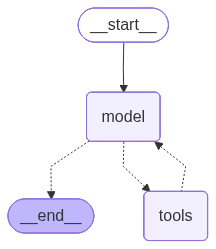

In [24]:
agent

#### 3.2.2.2 学习案例:温度单位转换

In [40]:
# from langchain.agents import create_agent # 最新 1.x 推荐入口
from pydantic import BaseModel, Field
from typing import Literal

# ======================
# 1. 环境变量
# ======================
# load_dotenv()
# API_KEY = os.getenv("API_KEY")
# BASE_URL = os.getenv("BASE_URL")

# llm = ChatOpenAI(
#     api_key=API_KEY,
#     base_url=BASE_URL,
#     model="deepseek-chat",
#     temperature=0.3,
# )

# ======================
# 2. 参数模型
# ======================
class TemperatureConvertInput(BaseModel):
    temperature: float = Field(description="需要转换的温度值，例如37.0")
    from_unit: str = Field(description="原始温度单位，只能是'celsius'（摄氏度）或'fahrenheit'（华氏度）")


# class TemperatureConvertInput(BaseModel):
#     temperature: float = Field(description="需要转换的温度值，例如37.0")
#     from_unit: Literal["celsius", "fahrenheit"] = Field(
#         description="原始温度单位，只能是 celsius 或 fahrenheit"
#     )  ## move all calibration to pydantic model, ensure input validity and simplify tool logic: suggested by codex

# ======================
# 3. 自定义工具
# ======================
@tool(args_schema=TemperatureConvertInput)
def temperature_converter(temperature: float, from_unit: str) -> str:
    """温度单位转换工具"""
    # """只支持摄氏度和华氏度之间的互相转换，不支持开尔文。"""
    if from_unit not in ["celsius", "fahrenheit"]:
        return f"错误：单位'{from_unit}'不合法，仅支持'celsius'或'fahrenheit'"
    
    if from_unit == "celsius":
        fahrenheit = temperature * 9/5 + 32
        return f"{temperature}摄氏度 = {fahrenheit:.2f}华氏度"
    else:
        celsius = (temperature - 32) * 5/9
        return f"{temperature}华氏度 = {celsius:.2f}摄氏度"

tools = [temperature_converter]

# ======================
# 4. Prompt模板（保留 agent_scratchpad）
# ======================
prompt = ChatPromptTemplate.from_messages([
    ("system",
     "你是一名专业温度转换助手，仅使用TemperatureConverter工具完成任务。"
     "严格校验参数，工具返回结果原样输出。"),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),  # 记录思考和工具调用
])

# ======================
# 5. 创建 Agent
# ======================
agent = create_agent(
    model=llm,
    tools=tools,
    debug=True,  # 👈 打开调试，显示模型调用过程
)


In [41]:

# ======================
# 6. 执行任务
# ======================
# if __name__ == "__main__":
    # 示例输入
query = "将237开尔文转换为华氏度"

# 调用 agent
response = agent.invoke({
    "messages": [{"role": "user", "content": query}]
})

# 输出最终回答
print("\n最终结果：")
print(response["messages"][-1].content)


[values] {'messages': [HumanMessage(content='将237开尔文转换为华氏度', additional_kwargs={}, response_metadata={}, id='3bb643dd-232c-4c1d-a201-92a030469fa6')]}
[updates] {'model': {'messages': [AIMessage(content='我需要先将开尔文转换为摄氏度，然后再转换为华氏度。\n\n开尔文转摄氏度的公式：°C = K - 273.15\n\n237K - 273.15 = -36.15°C\n\n现在将摄氏度转换为华氏度：', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 120, 'prompt_tokens': 335, 'total_tokens': 455, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256}, 'prompt_cache_hit_tokens': 256, 'prompt_cache_miss_tokens': 79}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'ac12767a-4791-44e9-8fd1-120e4195a741', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ee631-7da2-7670-9b81-845e9918d132-0', tool_calls=[{'name': 'temperature_converter', 'args': {'temperature': -36.15, 'from_unit': 'celsius'}

#### 3.2.3.1 学习案例：创建文件

In [42]:
# from langchain.agents import create_agent
# from langchain_openai import ChatOpenAI
from langchain_community.agent_toolkits import FileManagementToolkit
# from dotenv import load_dotenv
# import os

# -------------------
# 1. 初始化环境
# -------------------
# load_dotenv()
# API_KEY = os.getenv("API_KEY")
# BASE_URL = os.getenv("BASE_URL")

# llm = ChatOpenAI(
#     api_key=API_KEY,
#     base_url=BASE_URL,
#     model="deepseek-chat",
#     temperature=0.3,
# )

# -------------------
# 2. 创建文件管理工具
# -------------------
toolkit = FileManagementToolkit(root_dir=".")
tools = toolkit.get_tools()

# -------------------
# 3. 创建 Agent（最新版）
# -------------------
agent = create_agent(
    model=llm,
    tools=tools,
    debug=True,  # 打开调试，显示模型思考和工具调用过程
)


C:\Users\wkqia\AppData\Local\Temp\ipykernel_16368\3538871960.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.agent_toolkits import FileManagementToolkit


In [ ]:

# -------------------
# 4. 执行任务
# -------------------
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "请创建一个名为 llm诗词.txt 的文件，并在文件中写入一首原创七言绝句，主题围绕科技与人文的融合。"}
    ]
})

print("\n任务执行完成！文件已写入。")
print("Agent最终输出：\n", response["messages"][-1].content)


### 3.3.1 实践1：带记忆的对话机器人

In [2]:
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
from langchain_experimental.tools import PythonREPLTool
import re
import os
from dotenv import load_dotenv

# -------------------------
# 1. 初始化环境与模型
# -------------------------
load_dotenv()
API_KEY = os.getenv("API_KEY")
BASE_URL = os.getenv("BASE_URL")

llm = ChatOpenAI(
    api_key=API_KEY,
    base_url=BASE_URL,
    model="deepseek-chat",
    temperature=0.3
)

calc_tool = PythonREPLTool()  # 数学计算工具
WINDOW_SIZE = 2  # 窗口记忆轮数

# -------------------------
# 2. 提示模板
# -------------------------
prompt = ChatPromptTemplate.from_messages([
    ("system", f"""
你是一名友好的个人助手，能记住最近{WINDOW_SIZE}轮对话。
如果用户问题包含数学计算，请先调用计算工具，再生成自然语言回答。
"""),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{input}")
])

# -------------------------
# 3. 工具调用逻辑
# -------------------------
def judge_and_calc(inputs):
    user_input = inputs["input"]
    
    calc_pattern = r"(\+|\-|\*|/|×|÷|=|计算|求和|求差|平方|立方|多少|等于)"
    if re.search(calc_pattern, user_input):
        # 提取表达式（简化版）
        expr = re.sub(r"[^\d\+\-\*\/\(\)\.]", "", user_input)
        calc_result = calc_tool.run(expr) if expr else "未识别到可计算的表达式"
        inputs["input"] = f"用户问题：{user_input}\n计算结果：{calc_result}\n请结合计算结果回答"
    return inputs

# -------------------------
# 4. 窗口记忆管理
# -------------------------
window_memory_store = {}

def get_window_session_history(session_id: str):
    if session_id not in window_memory_store:
        window_memory_store[session_id] = InMemoryChatMessageHistory()
    history = window_memory_store[session_id]
    # 保留最近N轮
    total = len(history.messages)
    if total > 2 * WINDOW_SIZE:
        history.messages = history.messages[-2 * WINDOW_SIZE:]
    return history

# -------------------------
# 5. 构建链
# -------------------------
chain = (
    RunnablePassthrough.assign(chat_history=lambda x: x.get("chat_history", []))
    | RunnableLambda(judge_and_calc)
    | prompt
    | llm
)

chain_with_memory = RunnableWithMessageHistory(
    runnable=chain,
    get_session_history=get_window_session_history,
    input_messages_key="input",
    history_messages_key="chat_history",
    output_messages_key="output"
)

# -------------------------
# 6. 预设对话列表（模拟用户输入）
# -------------------------
predefined_dialogues = [
    "你好，我今天想问一下37摄氏度是多少华氏度？",
    "如果把212华氏度转换成摄氏度是多少？",
    "帮我算一下 15 + 28 × 2",
    "谢谢你，今天的温度真热啊"
]

# -------------------------
# 7. 模拟多轮对话执行
# -------------------------
if __name__ == "__main__":
    session_id = "student_001"
    print("===== 窗口记忆数学助手（预设对话） =====\n")
    
    for idx, user_input in enumerate(predefined_dialogues, 1):
        print(f"用户：{user_input}")
        
        response = chain_with_memory.invoke(
            {"input": user_input},
            config={"configurable": {"session_id": session_id}}
        )
        
        print(f"助手：{response.content}\n")


===== 窗口记忆数学助手（预设对话） =====

用户：你好，我今天想问一下37摄氏度是多少华氏度？
助手：37摄氏度换算成华氏度是 **98.6华氏度**。  
如果你有其他温度需要换算，或者有其他问题，随时告诉我！

用户：如果把212华氏度转换成摄氏度是多少？
助手：212华氏度换算成摄氏度是 **100摄氏度**。  
这个温度正好是水的沸点（在标准大气压下），所以它是个很常见的参考值！有其他问题可以继续问我哦。

用户：帮我算一下 15 + 28 × 2
助手：根据数学运算顺序（先乘除后加减），计算如下：

\[
15 + 28 \times 2 = 15 + 56 = 71
\]

所以结果是 **71**。  
有其他需要计算的题目，随时告诉我！

用户：谢谢你，今天的温度真热啊
助手：不客气！确实，最近天气越来越热了，记得多喝水、注意防暑降温哦～ 🌞  
如果还有其他问题或需要帮忙的地方，随时告诉我！



### 3.3.2 实践2：带记忆的文件夹操作助手

In [ ]:
# =========================
# 1. 基础依赖
# =========================
import os
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain.agents import create_agent

from langchain_core.messages import AIMessage, ToolMessage

# =========================
# 2. 模型
# =========================
load_dotenv()

llm = ChatOpenAI(
    api_key=os.getenv("API_KEY"),
    base_url="https://api.deepseek.com",
    model="deepseek-chat",
    temperature=0.3
)

# =========================
# 3. 记忆
# =========================
WINDOW_SIZE = 3
memory_store = {}

def get_session_history(session_id: str):
    if session_id not in memory_store:
        memory_store[session_id] = InMemoryChatMessageHistory()

    history = memory_store[session_id]

    if len(history.messages) > 2 * WINDOW_SIZE:
        history.messages = history.messages[-2 * WINDOW_SIZE:]

    return history

# =========================
# 4. 工具
# =========================
@tool
def list_files(path: str = ".") -> str:
    """查看指定目录下的文件列表"""
    if not os.path.exists(path):
        return f"路径不存在：{path}"

    items = os.listdir(path)
    if not items:
        return "目录为空"

    result = []
    for item in items:
        full = os.path.join(path, item)
        if os.path.isfile(full):
            result.append(f"文件：{item}（{os.path.getsize(full)} 字节）")
        else:
            result.append(f"文件夹：{item}")

    return "\n".join(result)


@tool
def create_file(path: str, content: str = "") -> str:
    """创建文件并写入内容"""
    folder = os.path.dirname(path)
    if folder and not os.path.exists(folder):
        os.makedirs(folder)

    with open(path, "w", encoding="utf-8") as f:
        f.write(content)

    return f"文件已创建：{path}"

tools = [list_files, create_file]

# =========================
# 5. 创建 Agent
# =========================
agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="你是一个文件操作智能助手。"
)

agent_with_memory = RunnableWithMessageHistory(
    agent,
    get_session_history,
    input_messages_key="messages",
    history_messages_key="messages"
)

# =========================
# 6. CLI
# =========================
if __name__ == "__main__":
    session_id = "tool_agent_demo"

    print("===== 🧠 LangChain v1.2 Agent =====")

    while True:
        user_input = input("你：")

        if user_input in ["q", "quit", "退出"]:
            print("助手：再见 👋")
            break

        # ✅ 打印用户输入
        print("\n👤【用户输入】")
        print(user_input)

        result = agent_with_memory.invoke(
            {
                "messages": [
                    {"role": "user", "content": user_input}
                ]
            },
            config={"configurable": {"session_id": session_id}}
        )

        messages = result["messages"]

        # =====================
        # ✅ 打印工具调用过程
        # =====================
        print("\n🧠【Agent执行过程】")

        for msg in messages:
            # ===== AI 决定调用工具 =====
            if isinstance(msg, AIMessage) and msg.tool_calls:
                for call in msg.tool_calls:
                    print("\n🔧 AI 决定调用工具")
                    print("工具名：", call["name"])
                    print("参数：", call["args"])

            # ===== 工具返回结果 =====
            if isinstance(msg, ToolMessage):
                print("\n📦 工具执行结果")
                print(msg.content)

        # =====================
        # ✅ 最终回答
        # =====================
        print("\n✅【最终回答】")
        print(messages[-1].content)
        print()


===== 🧠 LangChain v1.2 Agent =====

👤【用户输入】

